## BETA AND CORRELATION UNDER IDIOSYNCRATIC RETURNS

Empirically tests how idiosyncratic (noise) returns affect an asset's estimated beta and its correlation to the market, starting from the alpha/beta/noise return decomposition and simulating returns with geometric Brownian motion.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library imports

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np

### Theory -- return decomposition into alpha, beta, and noise

The single-index model decomposes an asset's return into a market-driven
(systematic) component and an idiosyncratic (noise) component:

$$r_i(t) = \alpha_i + \beta_i \, r_m(t) + \epsilon_i(t)$$

with $\epsilon_i$ uncorrelated with $r_m$ and, across names, uncorrelated with
$\epsilon_j$. Under that assumption, variance splits additively into a
systematic and an idiosyncratic piece:

$$\operatorname{Var}(r_i) = \beta_i^2 \operatorname{Var}(r_m) + \operatorname{Var}(\epsilon_i)$$

and the fraction of variance explained by the market is
$R_i^2 = \beta_i^2 \operatorname{Var}(r_m) / \operatorname{Var}(r_i)$.

Because idiosyncratic noise is uncorrelated across names, the covariance
between two assets comes entirely from their shared exposure to the market:

$$\operatorname{Cov}(r_i, r_j) = \beta_i \beta_j \operatorname{Var}(r_m)
\quad\Rightarrow\quad
\operatorname{corr}(r_i, r_j) = \sqrt{R_i^2 \, R_j^2}$$

This is the mechanism under test: adding idiosyncratic variance to an asset
leaves its *true* beta untouched but inflates $\operatorname{Var}(r_i)$, which
shrinks $R_i^2$ and therefore mechanically drives correlation toward zero --
with no change in the underlying factor exposure.

The OLS estimator of beta from a return sample is
$\hat\beta_i = \operatorname{Cov}(r_i, r_m) / \operatorname{Var}(r_m)$. Since
$\epsilon_i$ is uncorrelated with $r_m$, $\hat\beta_i$ is unbiased for any
level of idiosyncratic noise -- but its sampling variance,
$\operatorname{Var}(\hat\beta_i) = \operatorname{Var}(\epsilon_i) / (n \operatorname{Var}(r_m))$,
grows with idiosyncratic variance. So the prediction is: idio noise should
leave the *estimated* beta centered on its true value (just noisier), while
it mechanically compresses correlation. We test both halves below.

**Note -- alpha affects neither beta nor correlation.** $\alpha_i$ is a constant
(non-random) shift, and covariance is invariant to constants:
$\operatorname{Cov}(\alpha_i + X, Y) = \operatorname{Cov}(X, Y)$ for any constant
$\alpha_i$. So $\alpha_i$ changes only $E[r_i]$ -- it leaves
$\operatorname{Var}(r_i)$, $\operatorname{Cov}(r_i, r_m)$, and therefore both
$\hat\beta_i$ and $\operatorname{corr}(r_i, r_j)$ exactly unchanged, at any
magnitude. The same argument applies to any deterministic (non-random) shift
in $\epsilon_i$'s mean, such as the Itô convexity correction used below --
only the *variance* of the idiosyncratic term matters for beta and correlation,
never its level.

### Simulation design

We simulate a market factor and a family of single-asset return series via
geometric Brownian motion. Log returns are normal, so a linear combination
$r_i = \beta_i r_m + \epsilon_i$ with independent normal $\epsilon_i$ is itself
normal, and $P_i(t) = P_i(0) \exp(\sum_{s \le t} r_i(s))$ remains a valid GBM
price path.

All assets share the same true beta ($1.2$) and zero alpha; only the annualized
idiosyncratic volatility varies. For each idio-vol level we run many Monte
Carlo trials of a multi-year daily return path, then measure the realized
correlation to the market and the OLS beta estimate in each trial.

In [3]:
rng = np.random.default_rng(42)

beta_true = 1.2
mu_m = 0.08
sigma_m = 0.20
dt = 1 / 252
n_periods = 252 * 5
n_trials = 2_000
idio_vols = np.array([0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 1.0])

market_shocks = rng.standard_normal((n_trials, n_periods))
market_returns = (mu_m - 0.5 * sigma_m**2) * dt + sigma_m * np.sqrt(dt) * market_shocks

market_var = market_returns.var(axis=1)
market_mean = market_returns.mean(axis=1)

In [4]:
corr_mean = np.empty(len(idio_vols))
corr_std = np.empty(len(idio_vols))
beta_hat_mean = np.empty(len(idio_vols))
beta_hat_std = np.empty(len(idio_vols))

for k, idio_vol in enumerate(idio_vols):
    idio_shocks = rng.standard_normal((n_trials, n_periods))
    idio_returns = -0.5 * idio_vol**2 * dt + idio_vol * np.sqrt(dt) * idio_shocks
    asset_returns = beta_true * market_returns + idio_returns

    asset_mean = asset_returns.mean(axis=1)
    asset_var = asset_returns.var(axis=1)
    cov = (asset_returns * market_returns).mean(axis=1) - asset_mean * market_mean

    corr = cov / np.sqrt(asset_var * market_var)
    beta_hat = cov / market_var

    corr_mean[k] = corr.mean()
    corr_std[k] = corr.std()
    beta_hat_mean[k] = beta_hat.mean()
    beta_hat_std[k] = beta_hat.std()

theoretical_corr = (
    beta_true * sigma_m / np.sqrt(beta_true**2 * sigma_m**2 + idio_vols**2)
)

### Results

Correlation to the market against the theoretical curve
$\sqrt{R^2} = \beta \sigma_m / \sqrt{\beta^2 \sigma_m^2 + \sigma_\epsilon^2}$, and the
OLS beta estimate's mean and dispersion, both as a function of idiosyncratic
volatility.

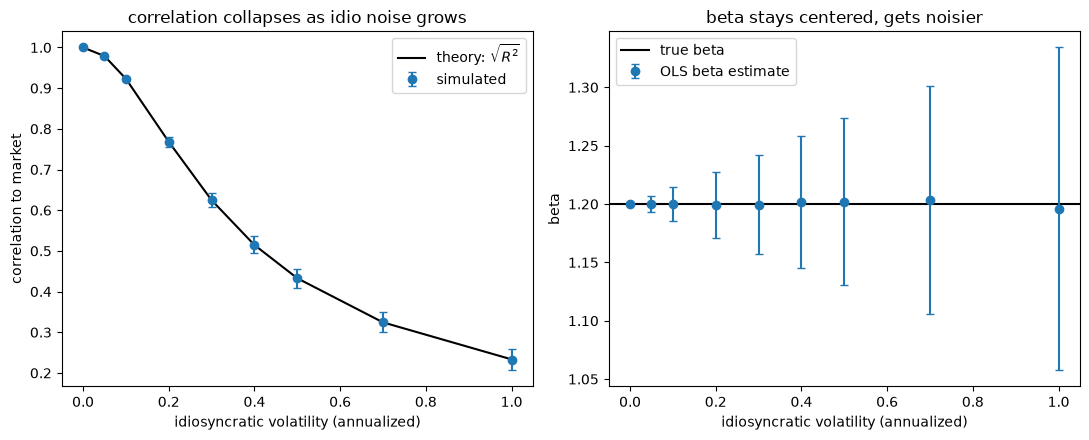

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.plot(idio_vols, theoretical_corr, label="theory: $\\sqrt{R^2}$", color="black")
ax.errorbar(
    idio_vols,
    corr_mean,
    yerr=corr_std,
    fmt="o",
    capsize=3,
    label="simulated",
)
ax.set_xlabel("idiosyncratic volatility (annualized)")
ax.set_ylabel("correlation to market")
ax.set_title("correlation collapses as idio noise grows")
ax.legend()

ax = axes[1]
ax.axhline(beta_true, color="black", label="true beta")
ax.errorbar(
    idio_vols,
    beta_hat_mean,
    yerr=beta_hat_std,
    fmt="o",
    capsize=3,
    label="OLS beta estimate",
)
ax.set_xlabel("idiosyncratic volatility (annualized)")
ax.set_ylabel("beta")
ax.set_title("beta stays centered, gets noisier")
ax.legend()

fig.tight_layout()
plt.show()

### Conclusion

The simulation confirms both halves of the theoretical prediction:

- **Beta is unbiased but noisier.** The OLS beta estimate stays centered on
  the true value ($1.2$) at every idiosyncratic volatility level -- adding
  idio noise doesn't shift the point estimate, since $\epsilon_i$ is
  uncorrelated with the market regressor. But its sampling dispersion widens
  steadily with idio vol, exactly as $\operatorname{Var}(\hat\beta) =
  \operatorname{Var}(\epsilon)/(n\operatorname{Var}(r_m))$ predicts.
- **Correlation is mechanically diluted.** Realized correlation to the market
  tracks the theoretical $\sqrt{R^2}$ curve closely, falling from $1.0$ at
  zero idio vol toward $0$ as idio vol dominates -- with no change in the
  underlying factor exposure. Correlation is not measuring "how similar two
  assets are'' in some causal sense; it is measuring how much of *both*
  assets' variance is explained by the shared factor, which idiosyncratic
  noise directly dilutes.

Practical implication: a low or falling correlation between an asset and the
market (or between two assets sharing a factor) does not by itself imply a
falling beta or reduced factor exposure -- it can be entirely explained by a
rise in idiosyncratic variance.